In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearnex import patch_sklearn
import os
import scanpy as sc
import skimage
from scipy import ndimage
from multiprocessing import Pool
from tqdm import tqdm
from skimage.io import imread
import scipy.ndimage as ndi
from scipy.ndimage import distance_transform_edt
from scipy.spatial.distance import cdist
from skimage.measure import regionprops,regionprops_table

In [3]:
def get_canny_edge_image(image, radius=30, sigma=0.5):
    """Compute Canny edge image."""
    from skimage.filters.rank import equalize
    from skimage.morphology import disk
    from skimage.feature import canny

    result = canny(image, sigma=sigma)
    return np.ma.array(result)
def lacunarity_evaluation(image, box_size=30):
    """
    From here: https://satsense.readthedocs.io/en/latest/_modules/satsense/features/lacunarity.html
    Calculate the lacunarity value over an image.

    The calculation is performed following these papers:

    Kit, Oleksandr, and Matthias Luedeke. "Automated detection of slum area
    change in Hyderabad, India using multitemporal satellite imagery."
    ISPRS journal of photogrammetry and remote sensing 83 (2013): 130-137.

    Kit, Oleksandr, Matthias Luedeke, and Diana Reckien. "Texture-based
    identification of urban slums in Hyderabad, India using remote sensing
    data." Applied Geography 32.2 (2012): 660-667.
    """
    import scipy
    kernel = np.ones((box_size, box_size))
    accumulator = scipy.signal.convolve2d(image, kernel, mode="valid")
    mean_sqrd = np.mean(accumulator) ** 2
    if mean_sqrd == 0:
        return 0.0
    return np.var(accumulator) / mean_sqrd + 1

In [147]:
collagen_tb[['fov','Leap_ID']].drop_duplicates()['Leap_ID'].nunique()

91

Define alignment

In [148]:
collagen_tb[collagen_tb['SAMPLE_TYPE_(CORE/RESECTION)']=='RESECTION'][['NACT_treatment _group','Leap_ID']].drop_duplicates()['NACT_treatment _group'].value_counts(dropna = False)

NACT_treatment _group
EC-T          13
NaN           12
EC-T-carbo     8
Name: count, dtype: int64

In [5]:
input_dir = "../../../Img_Denoised/contrast_adj/"
fiber_channel_name = 'Collage-Type_I'
base_dir = '.'
fibseg_dir = os.path.join(base_dir, 'fiber_segmentation_processed_data')
collagen_tb = pd.read_csv(os.path.join(fibseg_dir,'fiber_object_table.csv'))
collagen_tb.dropna(axis =0, inplace=True)
collagen_tb = collagen_tb[np.isfinite(collagen_tb.alignment_score)]#drop non finite elements
collagen_tb['Leap_ID'] = collagen_tb.fov.str.split('_',n = 1).str[0].str.upper()
biosamples_path = '/home/giuseppe/devices/Delta_Tissue/IMC/IMC_data/ExtraDocs/processed_response_RCB.csv'
biosamples =pd.read_csv(biosamples_path)
collagen_tb = collagen_tb.merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1)#add metadata on patient


In [6]:

ridge_cutoff = 0.15
sobel_blur = 5
min_fiber_size = 100
def extract_features(acq_id):
    #img = skimage.io.imread('../fiber_segmentation_processed_data/'+acq_id+'_fiber_labels.tiff')
    collagen = skimage.io.imread(os.path.join('/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/contrast_adj/'+acq_id+'/Collage-Type_I.tiff'))
    fg_thr = skimage.filters.threshold_otsu(collagen)#foreground threshold
    collagen = collagen>fg_thr
    seg = imread(os.path.join('../../../segmentation/deepcell_output_Denoised/',acq_id+'_whole_cell.tiff'))
    area =collagen.sum()/np.prod(collagen.shape)#fraction of ROI occupied by segmented collagen fibers
    #overlap = np.sum((collagen>0)*(seg>0),axis = None)/np.sum((collagen>0)|(seg>0),axis = None)#fraction of the fiber area where cells overlap
    overlap = np.sum((collagen>0)*(seg>0),axis = None)/np.sum((collagen>0),axis = None)#fraction of the fiber area where cells overlap
    distance_transformed = ndi.gaussian_filter(
    distance_transform_edt(collagen > ridge_cutoff),
    sigma=1)
    #distance_transfodistance_transformed gives, for each pixel,  the closest distance to the background 
    compactness=distance_transformed.mean()#a measure of how compact the fiber region is     
    diagonal = np.sqrt((np.array(collagen.shape)**2).sum())#compute the diagonal
    perimeter =regionprops(collagen.astype(np.uint8))[0].perimeter_crofton/diagonal
    solidity =regionprops(collagen.astype(np.uint8))[0].solidity
    lacunarity=lacunarity_evaluation(collagen)
    inertia_eigs=np.array(regionprops(collagen.astype(np.uint8))[0].inertia_tensor_eigvals)/diagonal**2
    mean_fiber_lenght =get_canny_edge_image(collagen,sigma = 3).mean()
    canny = get_canny_edge_image(collagen,sigma = 3)

    sobel_h = ndimage.sobel(collagen.astype(float), 0)  # horizontal gradient
    sobel_v = ndimage.sobel(collagen.astype(float), 1)  # vertical gradient
    direction = np.arctan2(sobel_v,sobel_h)
    z = np.exp((direction%np.pi)[canny]*1j)
    circular_variance=1-np.absolute(np.mean(z))#circular variance https://en.wikipedia.org/wiki/Directional_statistics#The_fundamental_difference_between_linear_and_circular_statistics
    names = ['area_all','overlap','compactness','perimeter','solidity','lacunarity','lenght',       'circular_variance','inertia_eigs_1','inertia_eigs_2']
    values =[area,       overlap,  compactness,  perimeter,  solidity,  lacunarity,mean_fiber_lenght,circular_variance,*inertia_eigs]
    return dict(zip(names,values))
pool = Pool()
collagen_global_properties = pool.map( extract_features,collagen_tb.fov.unique())
collagen_global_properties = pd.DataFrame(collagen_global_properties,index = collagen_tb.fov.unique())
collagen_global_properties['Leap_ID'] = collagen_global_properties.index.str.split('_',n = 1).str[0].str.upper()
collagen_global_properties = collagen_global_properties.reset_index(names = 'fov').merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1)#add metadata on patient
collagen_global_properties['group_type'] = collagen_global_properties['SAMPLE_TYPE_(CORE/RESECTION)'].where(collagen_global_properties['SAMPLE_TYPE_(CORE/RESECTION)'] == 'CORE',collagen_global_properties['NACT_treatment _group'])


In [23]:
columns_additional = set(collagen_global_properties.columns).difference(biosamples.columns)
columns_additional = list(columns_additional.difference(['Leap_ID','group_type','fov']))


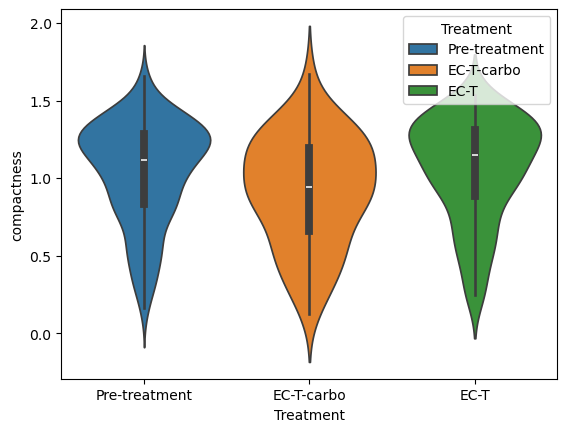

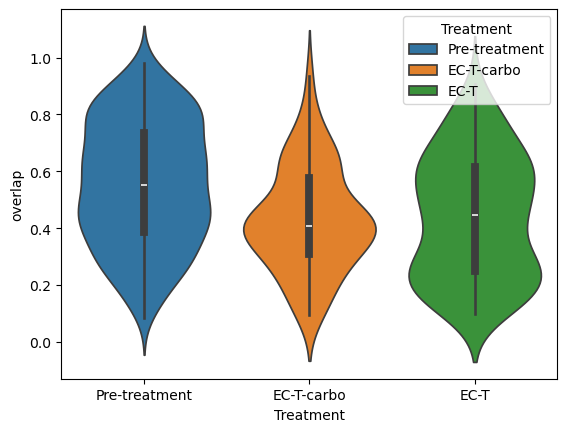

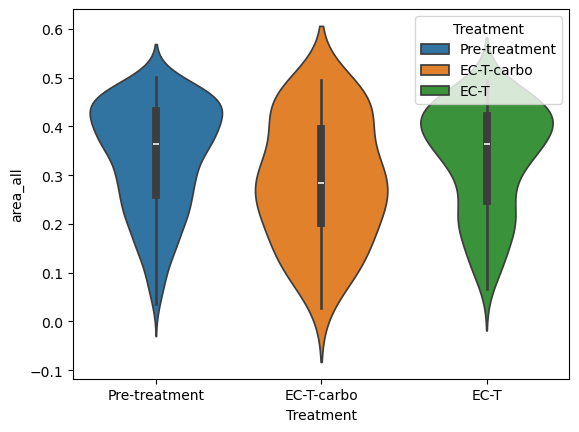

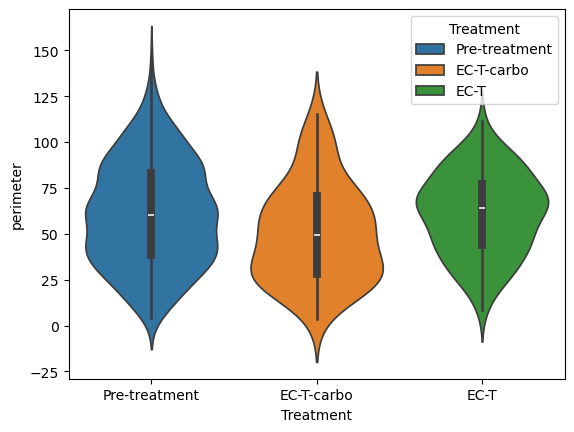

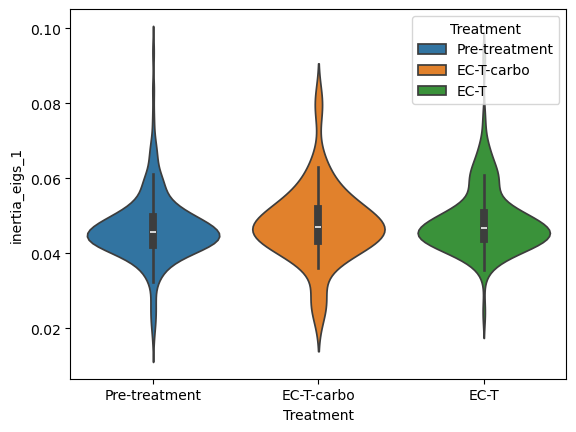

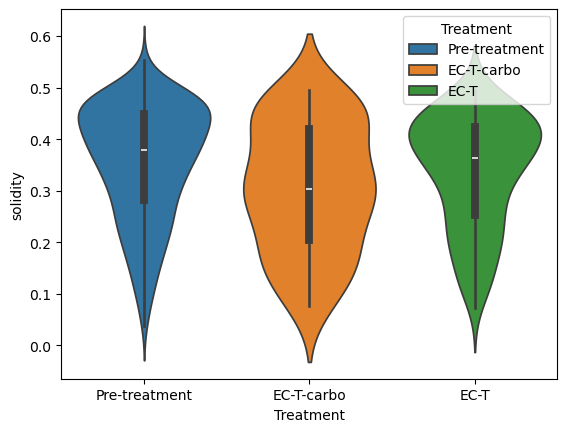

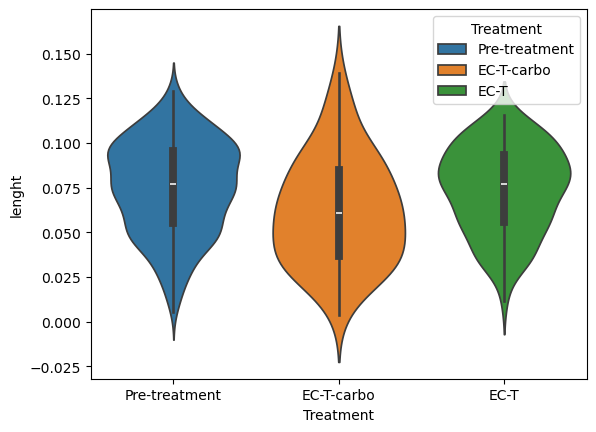

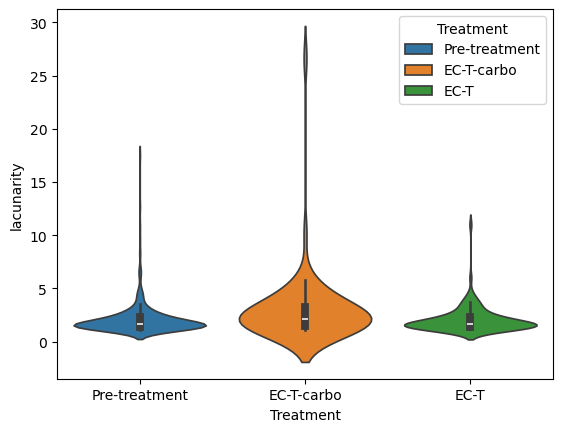

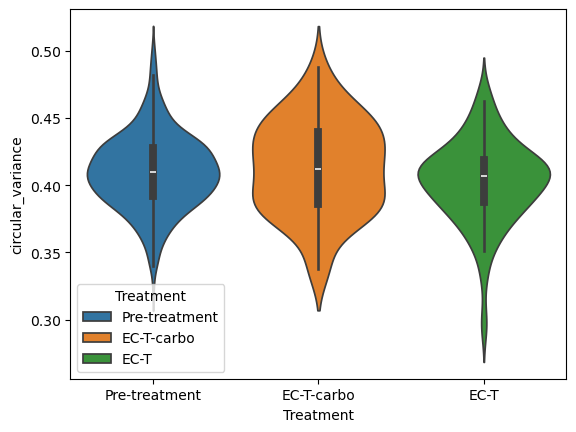

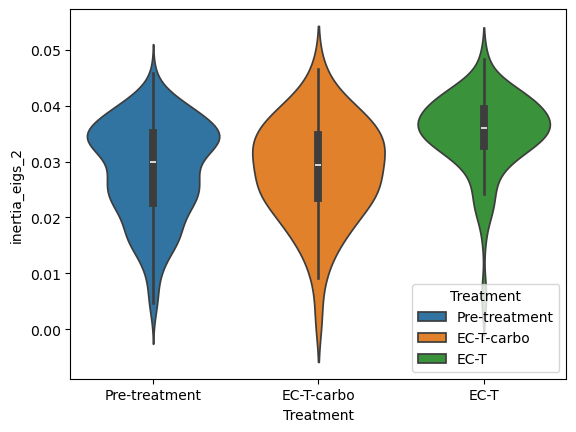

<Figure size 640x480 with 0 Axes>

In [24]:
collagen_red = collagen_global_properties.drop(['SAMPLE_TYPE_(CORE/RESECTION)','NACT_treatment _group'],axis = 1).loc[:,columns_additional+['Leap_ID','group_type','fov']]
collagen_red = collagen_red.replace({'CORE':'Pre-treatment'}).rename({'group_type':'Treatment'},axis = 1)
for col in columns_additional:
    sns.violinplot(collagen_red,x ='Treatment', y = col,hue = 'Treatment',common_norm=False)
    plt.figure()


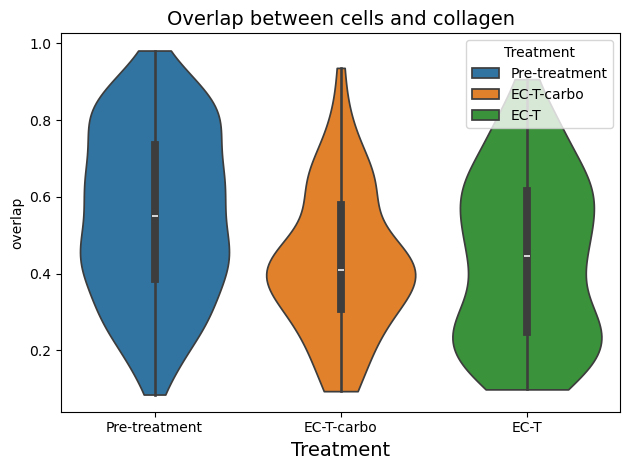

In [41]:
sns.violinplot(collagen_red,x ='Treatment', y = 'overlap',hue = 'Treatment',common_norm=False,cut = 0)
plt.xlabel('Treatment',fontsize = 14)
plt.title('Overlap between cells and collagen',fontsize = 14)
plt.tight_layout()
#plt.savefig('figures/overlap_treatment.png')

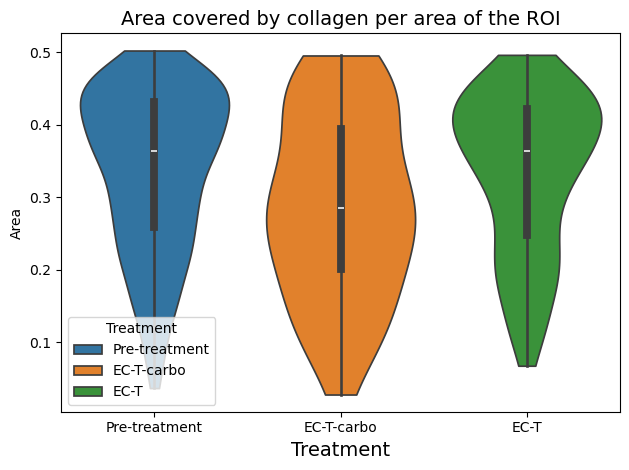

In [42]:
sns.violinplot(collagen_red,x ='Treatment', y = 'area_all',hue = 'Treatment',common_norm=False,cut = 0)
plt.xlabel('Treatment',fontsize = 14)
plt.title('Area covered by collagen per area of the ROI',fontsize = 14)
plt.tight_layout()
plt.ylabel('Area')
#plt.savefig('figures/area_treatment.png')

The effect of carboplatin is:
- overlap between collagen fibers and cells
- inertia eigenvalues

In [44]:
a = sc.AnnData(collagen_global_properties.loc[:,columns_additional],obs = collagen_global_properties[['SAMPLE_TYPE_(CORE/RESECTION)','NACT_treatment _group','group_type','fov',]])
sc.tl.rank_genes_groups(a,groupby='SAMPLE_TYPE_(CORE/RESECTION)')
sc.get.rank_genes_groups_df(a,group='CORE')

/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/giuseppe/anaconda3/lib/python3.9/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()


,names,scores,logfoldchanges,pvals,pvals_adj
0,overlap,8.216768,0.524122,1.711495e-15,1.711495e-14
1,solidity,1.427962,0.064952,1.539732e-01,3.849331e-01
2,lenght,1.035096,0.045809,3.011618e-01,5.225075e-01
3,circular_variance,0.905424,0.009685,3.657552e-01,5.225075e-01
4,perimeter,0.402242,1.225514,6.876651e-01,7.632895e-01
5,area_all,0.301343,0.014324,7.632895e-01,7.632895e-01
6,compactness,-0.802486,-0.049079,4.226811e-01,5.283514e-01
7,lacunarity,-0.957658,-0.240054,3.388668e-01,5.225075e-01
8,inertia_eigs_1,-2.442949,-0.054157,1.491005e-02,4.970017e-02
9,inertia_eigs_2,-6.601254,-0.214835,1.027562e-10,5.137812e-10


In [127]:
resection = collagen_global_properties[collagen_global_properties['SAMPLE_TYPE_(CORE/RESECTION)']=='RESECTION']
r = sc.AnnData(resection.loc[:,columns_additional],obs = resection[['NACT_treatment _group','group_type','fov',]])
sc.tl.rank_genes_groups(r,groupby='NACT_treatment _group')
sc.get.rank_genes_groups_df(r,group='EC-T')

/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/giuseppe/anaconda3/lib/python3.9/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()


,names,scores,logfoldchanges,pvals,pvals_adj
0,inertia_eigs_2,3.752353,0.170917,0.000222,0.002221
1,overlap,1.518324,0.169826,0.130409,0.434696
2,inertia_eigs_1,0.801841,0.027491,0.423501,0.667127
3,perimeter,0.721733,3.304214,0.471194,0.667127
4,lenght,0.623316,0.044975,0.533702,0.667127
5,area_all,-0.089693,-0.006960,0.928610,0.928610
6,compactness,-0.323626,-0.031894,0.746516,0.829463
7,solidity,-0.741515,-0.055411,0.459137,0.667127
8,lacunarity,-1.216166,-0.515963,0.225554,0.563885
9,circular_variance,-2.272410,-0.040495,0.023988,0.119938


In [123]:
sc.get.rank_genes_groups_df(a,group='RESECTION')

/home/giuseppe/anaconda3/lib/python3.9/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()


,names,scores,logfoldchanges,pvals,pvals_adj
0,inertia_eigs_2,6.601254,0.214835,1.027562e-10,5.137812e-10
1,inertia_eigs_1,2.442949,0.054157,1.491005e-02,4.970017e-02
2,lacunarity,0.957658,0.240054,3.388668e-01,5.225075e-01
3,compactness,0.802486,0.049079,4.226811e-01,5.283514e-01
4,area_all,-0.301343,-0.014324,7.632895e-01,7.632895e-01
5,perimeter,-0.402242,-1.225514,6.876651e-01,7.632895e-01
6,circular_variance,-0.905424,-0.009685,3.657552e-01,5.225075e-01
7,lenght,-1.035096,-0.045809,3.011618e-01,5.225075e-01
8,solidity,-1.427962,-0.064952,1.539732e-01,3.849331e-01
9,overlap,-8.216768,-0.524122,1.711495e-15,1.711495e-14


In [112]:
a.uns['rank_genes_groups'].keys()

dict_keys(['params', 'names', 'scores', 'pvals', 'pvals_adj', 'logfoldchanges'])

In [238]:
core = collagen_tb[collagen_tb['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE']
resection = collagen_tb[collagen_tb['SAMPLE_TYPE_(CORE/RESECTION)']=='RESECTION']

In [239]:
resection[['Leap_ID','NACT_treatment _group']].drop_duplicates()['NACT_treatment _group'].value_counts()

NACT_treatment _group
EC-T          13
EC-T-carbo     8
Name: count, dtype: int64

In [240]:
a =resection[['Leap_ID','NACT_treatment _group']].drop_duplicates()
resection[resection.Leap_ID.isin(a[a['NACT_treatment _group']=='EC-T-carbo'].Leap_ID)].fov.unique()

array(['Leap002_1', 'Leap002_3', 'Leap002_4', 'Leap002_5', 'Leap002_6',
       'Leap002_7', 'Leap004_1', 'Leap004_2', 'Leap004_3', 'Leap004_4',
       'Leap004_5', 'Leap004_6', 'Leap004_7', 'Leap004_8', 'Leap004_9',
       'Leap004_10', 'Leap004_11', 'Leap004_12', 'Leap004_13',
       'Leap006_1', 'Leap006_2', 'Leap006_3', 'Leap006_4', 'Leap016_3',
       'Leap016_4', 'Leap016_5', 'Leap016_6', 'Leap035_10', 'Leap035_11',
       'Leap035_12', 'Leap035_13', 'Leap045_6', 'Leap045_7', 'Leap045_8',
       'Leap045_9', 'Leap045_10', 'Leap045_11', 'Leap045_12',
       'Leap045_13', 'Leap045_14', 'Leap079_1', 'Leap079_2', 'Leap079_3',
       'Leap079_4', 'Leap079_5', 'Leap079_6', 'Leap079_7', 'Leap079_8',
       'Leap079_9', 'Leap081_1', 'Leap081_2', 'Leap081_3', 'Leap081_4',
       'Leap081_5', 'Leap081_6', 'Leap081_7', 'Leap081_8', 'Leap081_9',
       'Leap081_10', 'Leap081_11', 'Leap081_12'], dtype=object)

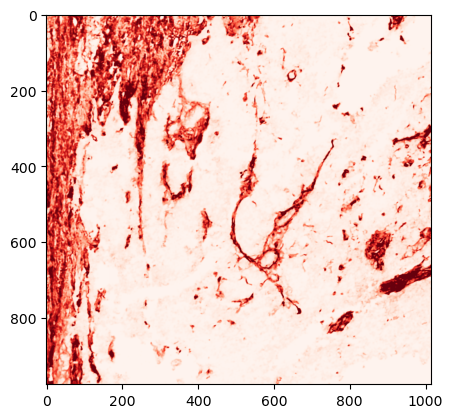

In [128]:
img = imread(os.path.join(input_dir,'Leap002_5',fiber_channel_name+'.tiff'))
carbo = imread(os.path.join(input_dir,'Leap002_5','Carboplatin.tiff'))
stacked = np.zeros((*img.shape,4))
plt.imshow(plt.cm.Reds(img))
stacked  = plt.cm.Purples(carbo)
stacked = np.clip(stacked, 0, 1)
#plt.imshow(plt.cm.Purples(carbo),alpha = 0.9)


In [196]:
b = pd.concat((a[[col]+['NACT_treatment _group']],core[[col]].drop_duplicates().assign(**{'NACT_treatment _group': 'CORE'})),axis = 0)
b

,inertia_eigs_2,NACT_treatment _group
125,44.306770,EC-T-carbo
164,46.552362,EC-T-carbo
220,19.524321,EC-T-carbo
281,49.681897,EC-T-carbo
335,31.770953,EC-T-carbo
...,...,...
22937,49.241807,CORE
22989,36.972321,CORE
23036,48.564441,CORE
23087,17.789865,CORE


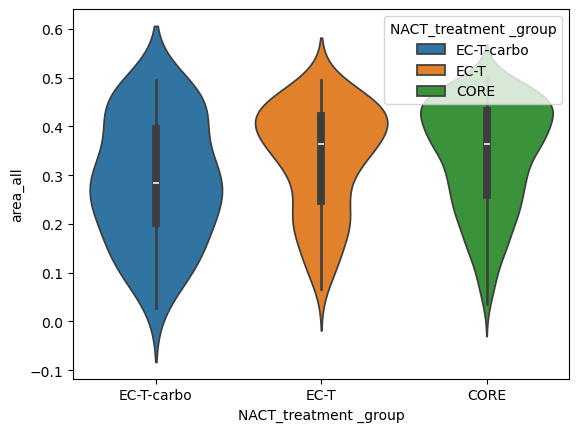

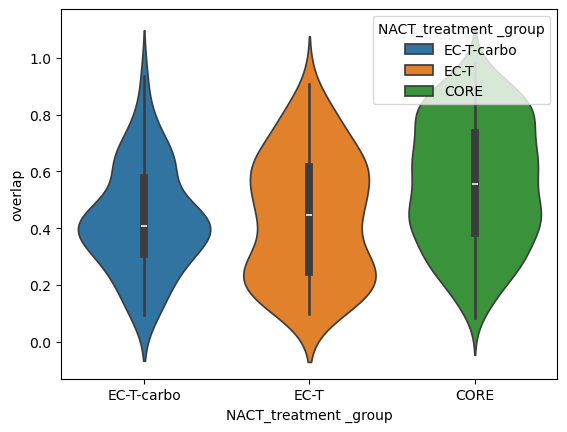

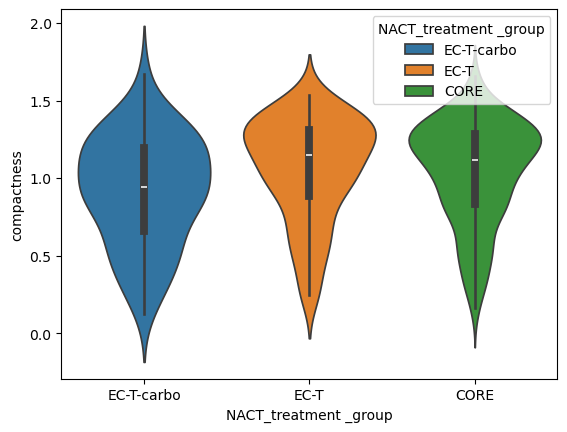

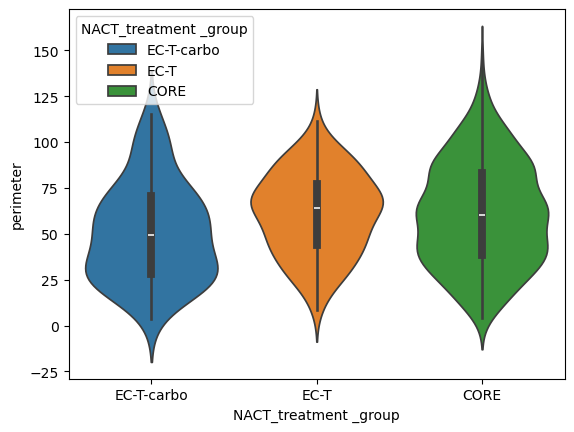

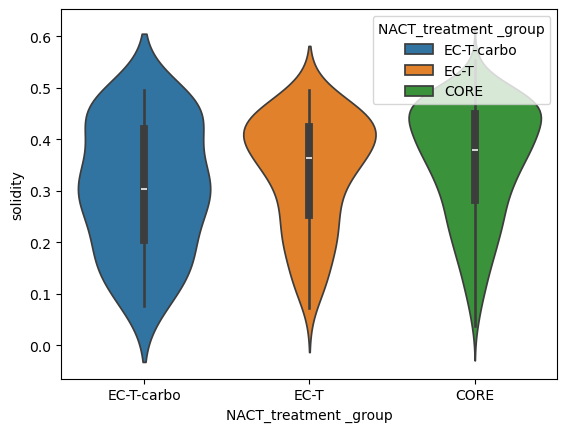

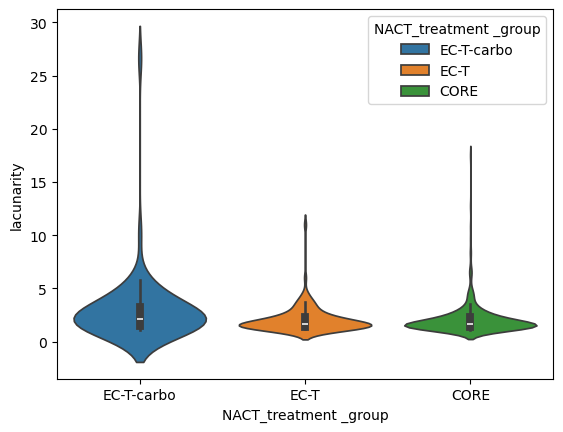

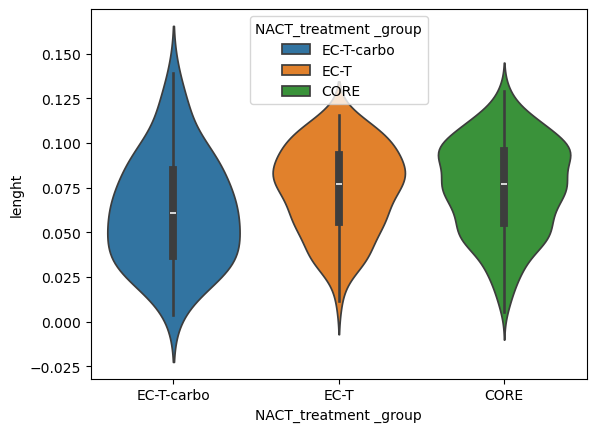

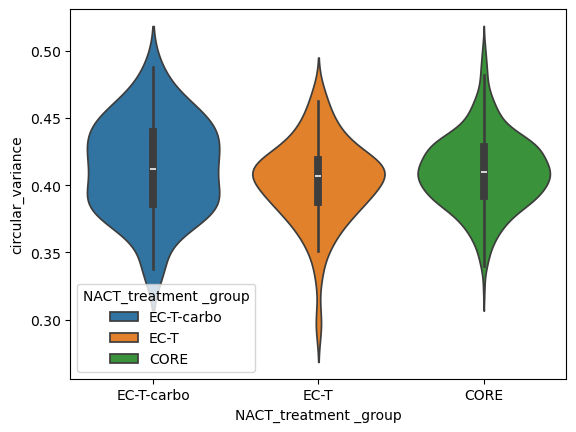

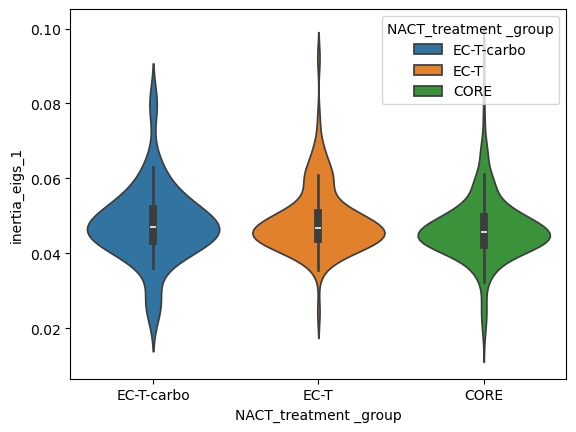

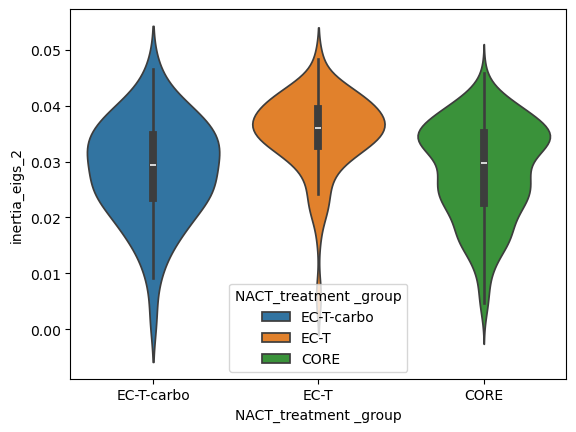

<Figure size 640x480 with 0 Axes>

In [241]:
a = resection[['fov','Leap_ID','SAMPLE_TYPE_(CORE/RESECTION)','NACT_treatment _group']+columns_additional].drop_duplicates()
for col in columns_additional:
    b = pd.concat((a[[col]+['NACT_treatment _group']],core[[col]].drop_duplicates().assign(**{'NACT_treatment _group': 'CORE'})),axis = 0)

    sns.violinplot(b,x ='NACT_treatment _group', y = col,hue = 'NACT_treatment _group')
    plt.figure()
    

In [53]:

a = collagen_tb.copy()
#a['condition'] = 
a['group_type'] = a['SAMPLE_TYPE_(CORE/RESECTION)'].where(a['SAMPLE_TYPE_(CORE/RESECTION)'] == 'CORE',a['NACT_treatment _group'])
a.drop(['SAMPLE_TYPE_(CORE/RESECTION)','NACT_treatment _group'],axis = 1).loc[:,columns_additional+['Leap_ID','group_type','']]

,area_all,overlap,compactness,perimeter,solidity,lacunarity,lenght,circular_variance,inertia_eigs_1,inertia_eigs_2,Leap_ID,group_type,fov
0,0.22171,0.802366,0.782471,44.292089,0.234265,2.392749,0.051617,0.413245,0.040530,0.023169,LEAP001,CORE,Leap001_8
1,0.22171,0.802366,0.782471,44.292089,0.234265,2.392749,0.051617,0.413245,0.040530,0.023169,LEAP001,CORE,Leap001_8
2,0.22171,0.802366,0.782471,44.292089,0.234265,2.392749,0.051617,0.413245,0.040530,0.023169,LEAP001,CORE,Leap001_8
3,0.22171,0.802366,0.782471,44.292089,0.234265,2.392749,0.051617,0.413245,0.040530,0.023169,LEAP001,CORE,Leap001_8
4,0.22171,0.802366,0.782471,44.292089,0.234265,2.392749,0.051617,0.413245,0.040530,0.023169,LEAP001,CORE,Leap001_8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23192,0.34025,0.532955,1.125410,88.552525,0.365109,1.839275,0.074218,0.457136,0.042425,0.033121,LEAP105,CORE,Leap105_9
23193,0.34025,0.532955,1.125410,88.552525,0.365109,1.839275,0.074218,0.457136,0.042425,0.033121,LEAP105,CORE,Leap105_9
23194,0.34025,0.532955,1.125410,88.552525,0.365109,1.839275,0.074218,0.457136,0.042425,0.033121,LEAP105,CORE,Leap105_9
23195,0.34025,0.532955,1.125410,88.552525,0.365109,1.839275,0.074218,0.457136,0.042425,0.033121,LEAP105,CORE,Leap105_9


In [49]:
biosamples

,LEAP_ID,SLIDE_NUMBER,BIOBANK_ID,SAMPLE_TYPE_(CORE/RESECTION),FORMAT_(FFPE/FROZEN),FORCE_TRIAL?_(Y/N),DATE_SECTIONED,H&E_NOTES,ST_NOTES,Response,COMMENTS,new_Response,Patient,Stain,Keep,extreme_non_responder,RCB_Group,NACT_treatment _group,RC_scores,diagnosis_year
0,LEAP001,1.0,19005858-FPE US (C)-1-FPEDiv-1,CORE,FFPE,NaN,21/06/2022,NaN,NaN,Non-Responder,CORE,nR,1,1,y,NaN,3.0,EC-T-carbo,3.750,2019.0
1,LEAP002,1.0,20001982-IncT FPE-1,RESECTION,FFPE,NaN,21/06/2022,NaN,NaN,Non-Responder,RESECTION,nR,1,1,y,NaN,3.0,EC-T-carbo,3.750,2019.0
2,LEAP003,2.0,21002266-FPE US (C)-1-FPEDiv-1,CORE,FFPE,NaN,21/06/2022,NaN,NaN,Non-Responder,CORE,nR,2,1,y,NaN,3.0,EC-T-carbo,3.834,2021.0
3,LEAP004,2.0,21001781-IncT FPE-2,RESECTION,FFPE,NaN,21/06/2022,NaN,NaN,Non-Responder,RESECTION,nR,2,1,y,NaN,3.0,EC-T-carbo,3.834,2021.0
4,LEAP005,3.0,22001707-FPE US (C)-2,CORE,FFPE,NaN,21/06/2022,NaN,NaN,Non-Responder,CORE,nR,3,1,y,NaN,2.0,EC-T-carbo,1.865,2019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,LEAP148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pCR,CORE,pCR,73,7,n,NaN,0.0,EC-T-carbo,0.000,2022.0
148,LEAP149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Non-Responder,CORE,nR,80,7,n,NaN,NaN,EC-T-carbo,NaN,2023.0
149,LEAP150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Non-Responder,CORE,nR,80,7,n,NaN,NaN,EC-T-carbo,NaN,2023.0
150,LEAP151,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Non-Responder,CORE,nR,102,7,n,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='NACT_treatment _group', ylabel='overlap'>

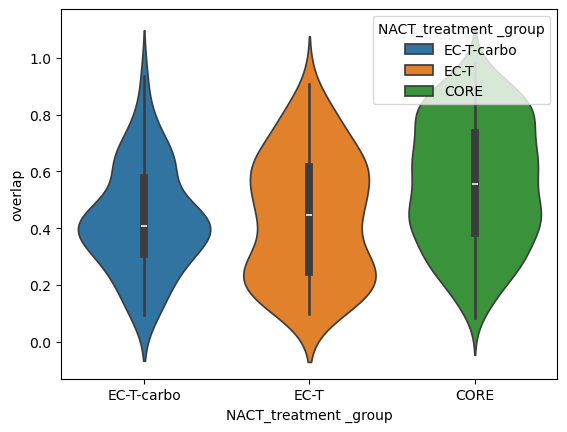

In [231]:
col = 'overlap'
b = pd.concat((a[[col]+['NACT_treatment _group']],core[[col]].drop_duplicates().assign(**{'NACT_treatment _group': 'CORE'})),axis = 0)

sns.violinplot(b,x ='NACT_treatment _group', y = 'overlap',hue = 'NACT_treatment _group')

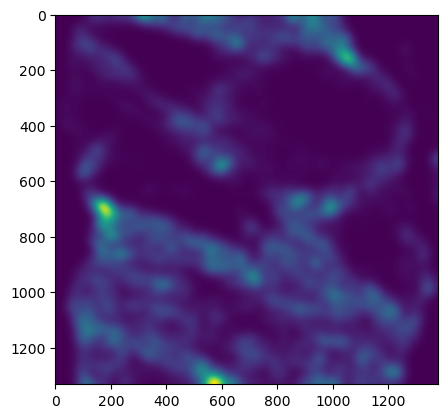

In [169]:
plt.imshow(ndi.gaussian_filter(
    distance_transform_edt(collagen > ridge_cutoff),
    sigma=20))

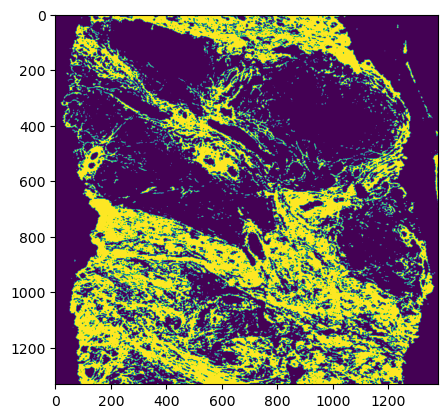

In [167]:
plt.imshow(collagen)